### 1. Import Required Libraries

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

### 2.  Load DataSet

In [111]:
df = pd.read_csv('../Data/Titanic-Dataset.csv')

In [112]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Understanding the Dataset

In [113]:
df.shape

(891, 12)

In [114]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [115]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [116]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

### 4.Data Cleaning

In [117]:
df.duplicated().sum()

np.int64(0)

In [118]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Missing Values in Age Column :177
Skewness of Age Column : 0.38910778230082704


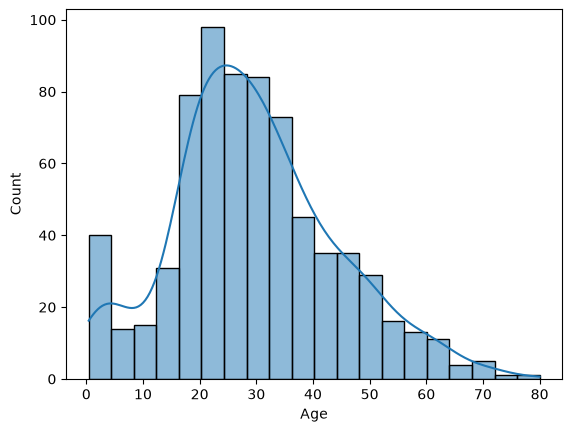

In [119]:
# 1. Missing values
print(f"Missing Values in Age Column :{df["Age"].isnull().sum()}")

# 2. Distribution
sns.histplot(df["Age"], kde=True)

# 3. Skewness
print(f"Skewness of Age Column : {df["Age"].skew()}")

In [120]:
df['Embarked'].values

<ArrowStringArray>
['S', 'C', 'S', 'S', 'S', 'Q', 'S', 'S', 'S', 'C',
 ...
 'S', 'S', 'S', 'S', 'Q', 'S', 'S', 'S', 'C', 'Q']
Length: 891, dtype: str

In [121]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [122]:
df['Age'] =df['Age'].fillna(df['Age'].median())
df['Age'].isna().sum()

np.int64(0)

4.787316519674893


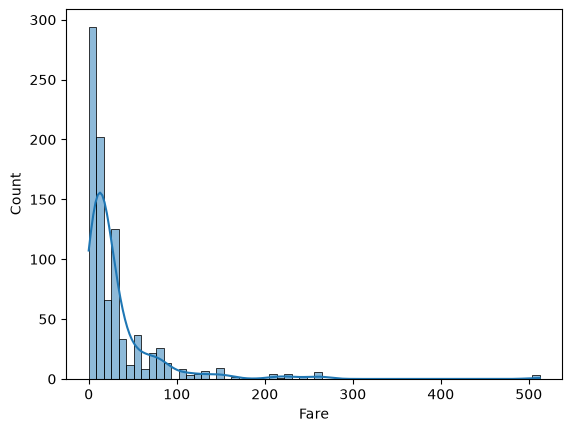

In [123]:
# Fare Histogram 
sns.histplot(df['Fare'],kde=True)

# Skewness
print(df['Fare'].skew())

### 5.Exploratory Data Analysis (EDA)

### 5.1 Target Values Distribution 

In [124]:
# Target Values Distribution 
print(df['Survived'].value_counts())


Survived
0    549
1    342
Name: count, dtype: int64


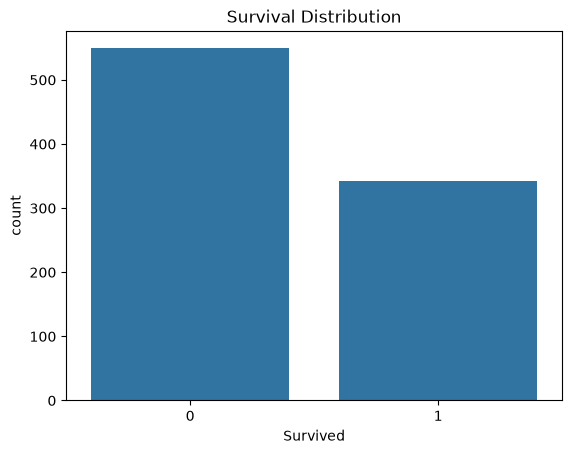

In [125]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Distribution")
plt.show()

### 5.2 Numerical Features Distribution

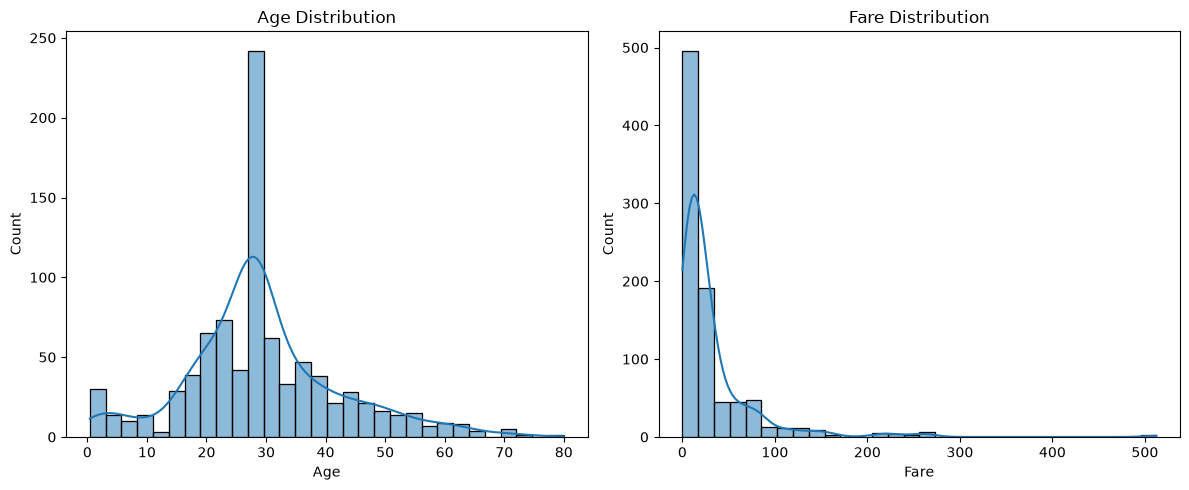

In [126]:
plt.figure(figsize=(12,5))

#age
plt.subplot(1,2,1)
sns.histplot(df['Age'],kde=True,bins=30)
plt.title("Age Distribution")

# Fare

plt.subplot(1,2,2)
sns.histplot(df['Fare'],kde=True,bins=30)
plt.title("Fare Distribution")

plt.tight_layout()
plt.show()

### 5.3 Categorical Features Distribution

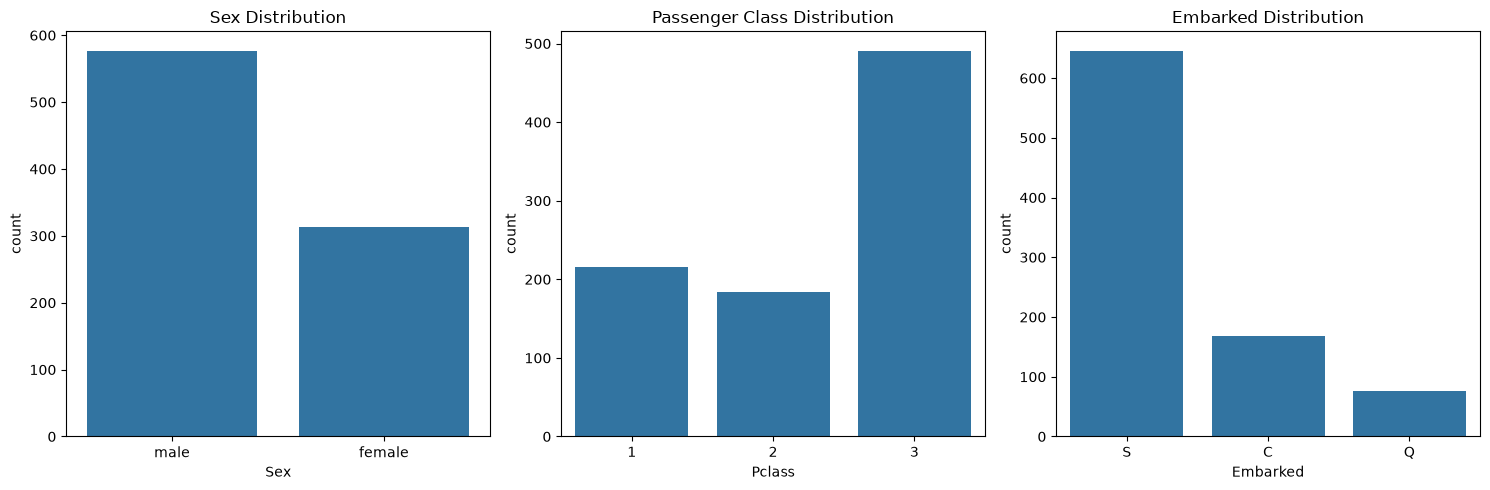

In [127]:
plt.figure(figsize=(15,5))

# Sex
plt.subplot(1,3,1)
sns.countplot(x="Sex", data=df)
plt.title("Sex Distribution")

# Passenger Class
plt.subplot(1,3,2)
sns.countplot(x="Pclass", data=df)
plt.title("Passenger Class Distribution")

# Embarked
plt.subplot(1,3,3)
sns.countplot(x="Embarked", data=df)
plt.title("Embarked Distribution")

plt.tight_layout()
plt.show()

#### 5.4 Correlation Heatmap

<Axes: >

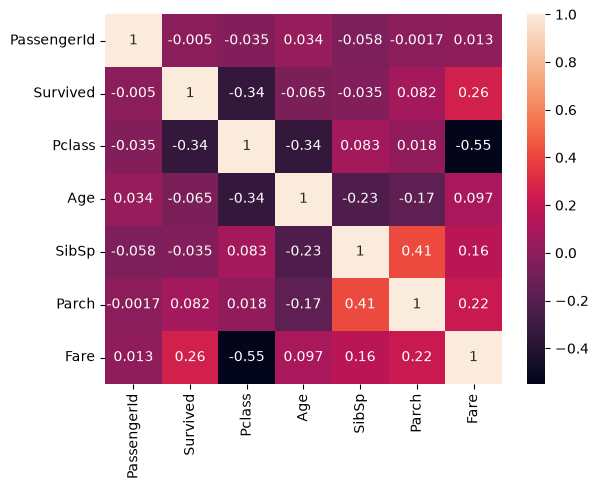

In [128]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

### 6. Feature Selection

In [129]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [130]:
df.drop(columns=["PassengerId","Name","Cabin","Ticket"],inplace=True)

In [131]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 60.8 KB


#### Feature Selection

The following features were removed:

PassengerId: Unique identifier, not useful for prediction.  
Name: High-cardinality text feature.  
Ticket: High-cardinality text feature.  
Cabin: More than 77% missing values.

### 7. Feature Encoding 
Feature encoding converts categorical features into numerical values because  
machine learning models require numerical input and cannot directly process categorical (text) data.

Examples include:
- Linear Regression
- Logistic Regression
- Decision Tree (scikit-learn)
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Neural Networks

In [133]:
# Encoding for Sex 
df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

In [134]:
# Encoding for Embarked 
df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


### 8.Define Features and Target

In [136]:
x = df.drop(columns=['Survived'])
y = df['Survived']

In [137]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,0,22.0,1,0,7.2500,0
1,1,1,38.0,1,0,71.2833,1
2,3,1,26.0,0,0,7.9250,0
3,1,1,35.0,1,0,53.1000,0
4,3,0,35.0,0,0,8.0500,0


In [138]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: Survived, dtype: int64

### 9.Train-Test Split

In [139]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=2,test_size=0.25)

In [140]:
print("Training Features :", x_train.shape)
print("Testing Features  :", x_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (668, 7)
Testing Features  : (223, 7)
Training Labels   : (668,)
Testing Labels    : (223,)


### 10.Build the Decision Tree Model

In [141]:
model = DecisionTreeClassifier(random_state=42)

In [142]:
model.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

### 11.Make Predictions

In [143]:
y_pred = model.predict(x_test)

### 12.Evaluate the Model

In [144]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [145]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test,y_pred)

In [146]:
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1 Score : {f1:.2f}")

Accuracy : 0.77
Precision: 0.73
Recall   : 0.70
F1 Score : 0.71


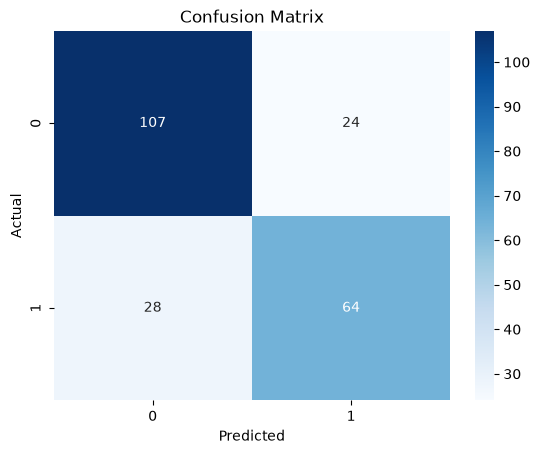

In [147]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Decision Tree Visualization

[Text(0.45689655172413796, 0.9, 'Sex <= 0.5\ngini = 0.468\nsamples = 668\nvalue = [418, 250]\nclass = Died'),
 Text(0.1896551724137931, 0.7, 'Age <= 13.0\ngini = 0.289\nsamples = 429\nvalue = [354, 75]\nclass = Died'),
 Text(0.3232758620689655, 0.8, 'True  '),
 Text(0.06896551724137931, 0.5, 'SibSp <= 2.0\ngini = 0.483\nsamples = 27\nvalue = [11, 16]\nclass = Survived'),
 Text(0.034482758620689655, 0.3, 'gini = 0.0\nsamples = 15\nvalue = [0, 15]\nclass = Survived'),
 Text(0.10344827586206896, 0.3, 'Age <= 3.5\ngini = 0.153\nsamples = 12\nvalue = [11, 1]\nclass = Died'),
 Text(0.06896551724137931, 0.1, '\n  (...)  \n'),
 Text(0.13793103448275862, 0.1, '\n  (...)  \n'),
 Text(0.3103448275862069, 0.5, 'Pclass <= 1.5\ngini = 0.25\nsamples = 402\nvalue = [343, 59]\nclass = Died'),
 Text(0.2413793103448276, 0.3, 'Age <= 38.5\ngini = 0.425\nsamples = 88\nvalue = [61.0, 27.0]\nclass = Died'),
 Text(0.20689655172413793, 0.1, '\n  (...)  \n'),
 Text(0.27586206896551724, 0.1, '\n  (...)  \n'),
 T

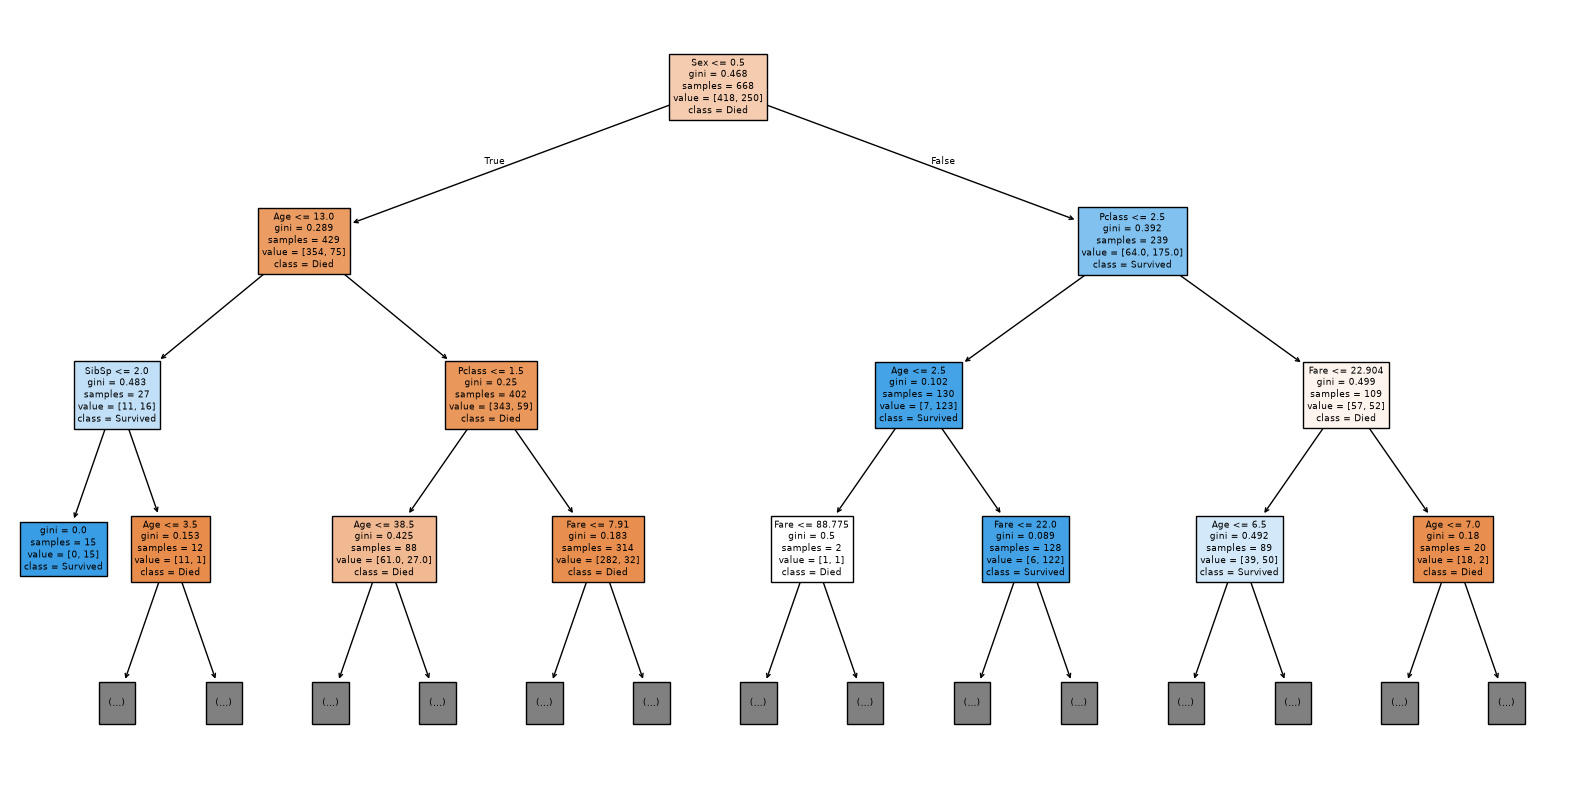

In [148]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model, feature_names=x.columns, class_names=['Died','Survived'], filled=True, max_depth=3)

### 13. Feature Importance

Feature importance shows how much each feature contributes to the Decision Tree model's predictions.

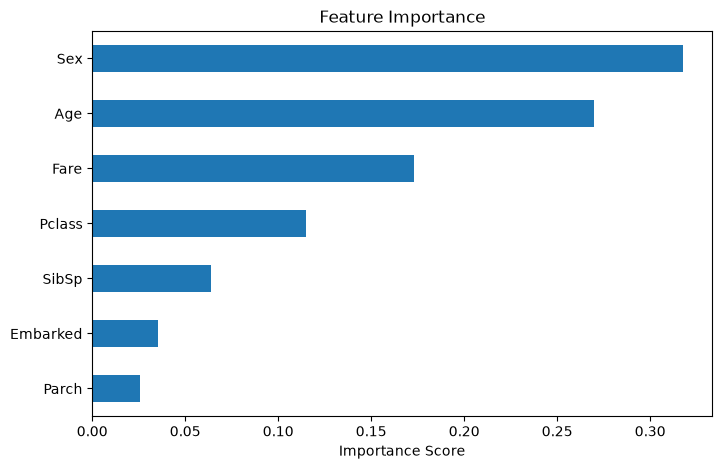

In [149]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=x.columns
)

feature_importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.show()

### 14. Classification Reports

In [150]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       131
           1       0.73      0.70      0.71        92

    accuracy                           0.77       223
   macro avg       0.76      0.76      0.76       223
weighted avg       0.77      0.77      0.77       223



### 15.Cross Validation

In [151]:
from sklearn.model_selection import cross_val_score

In [152]:
pipeline = Pipeline([
    ('model', DecisionTreeClassifier(random_state=42))
])

scores = cross_val_score(pipeline, x, y, cv=5)


In [153]:
print("Average Accuracy:", scores.mean())

Average Accuracy: 0.7778293892411023


### 16.Save the Model

In [154]:
import joblib
joblib.dump(model, "../Model/Decision_tree_model.pkl")

['../Model/Decision_tree_model.pkl']